<div style="font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;background:#0d1b2a;border-radius:10px;padding:18px 22px;color:#e6edf3;">
  <div style="display:flex;align-items:center;gap:12px;">
    <div style="width:6px;height:36px;background:#3fb950;border-radius:3px;flex:none;"></div>
    <div>
      <div style="font-size:11px;letter-spacing:2px;color:#8b98a5;">NOTEBOOK 02</div>
      <div style="font-size:21px;font-weight:700;line-height:1.15;">Preprocessing and Feature Engineering</div>
    </div>
  </div>
  <div style="font-size:13px;color:#a9b4c0;margin-top:9px;">Turn prices into a leakage-safe, event-level table: one row per extreme spread, with causal features and a forward reversion label.</div>
</div>

**Goal.** Build the supervised dataset. The unit of observation is an *extreme event*: a day on which a selected pair's spread z-score crosses |z| = 2.

**Timing rules (to avoid look-ahead leakage):**

1. **Pair selection** (hedge ratio, cointegration) uses the **formation window** only.
2. **Features** at event day *t* use information up to and including *t*.
3. The **label** uses the future window (*t*, *t* + horizon]: did |z| fall below the exit band?
4. The train/test split later is **by time**, never random.

This is the part of the project where a careless mistake silently inflates results, so the rules are enforced in `src/labeling.py`.

In [ ]:
import sys, os

from google.colab import drive
drive.mount('/content/drive')

# Function to find the project root containing the 'src' directory
def find_project_root():
    # List of potential base directories to search
    # Add current working directory and its parent directories to search paths
    _current_path = os.path.abspath(os.getcwd()) # This is typically /content in Colab
    potential_base_dirs = []
    _temp_path = _current_path
    while True:
        potential_base_dirs.append(_temp_path)
        if _temp_path == os.path.dirname(_temp_path): # Reached filesystem root '/'
            break
        _temp_path = os.path.dirname(_temp_path)

    # Also add the mounted Google Drive path as a potential base
    potential_base_dirs.append('/content/drive/MyDrive')

    for base_dir in potential_base_dirs:
        if not os.path.exists(base_dir):
            continue
        # Walk through the directories to find 'src'
        for dirpath, dirnames, filenames in os.walk(base_dir):
            if 'src' in dirnames:
                # Found a 'src' directory, the project root is its parent
                # For example, if src is found in /path/to/project/src,
                # then /path/to/project is the root.
                _project_root = dirpath
                return _project_root
    return None

_project_root = find_project_root()

if _project_root:
    # Only add to sys.path if it's not already there
    if _project_root not in sys.path:
        sys.path.insert(0, _project_root)
    print(f"Project root added to sys.path: {_project_root}")
else:
    print("Warning: 'src' directory not found in expected locations. Please ensure your project structure is correct or manually add the path to 'src' to sys.path.")


import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.config import CONFIG
from src.plotting import set_style, save_fig
set_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Data source: live Yahoo Finance via yfinance.
SOURCE = "yfinance"

In [11]:
from src.data import load_prices
from src.pairs import select_pairs
from src.labeling import build_event_dataset

prices, source = load_prices(source=SOURCE)
formation_days = CONFIG.pairs.formation_days
formation = prices.iloc[:formation_days]
print(f"source={source}")
print(f"formation: {formation.index[0].date()} -> {formation.index[-1].date()} ({len(formation)} days)")
print(f"scoring  : {prices.index[formation_days].date()} -> {prices.index[-1].date()}")

source=cache
formation: 2018-01-02 -> 2020-01-02 (504 days)
scoring  : 2020-01-03 -> 2026-05-29


## Pair selection on the formation window

In [12]:
pairs = select_pairs(formation)
print(f"{len(pairs)} pairs passed the correlation and cointegration gates")
pairs

3 pairs passed the correlation and cointegration gates


,a,b,corr,coint_pvalue,beta,half_life
0,AXP,MSFT,0.652,0.018,0.558,13.800
1,ADBE,MSFT,0.812,0.022,0.683,17.900
2,AMZN,GOOGL,0.693,0.036,0.826,28.900


In [5]:
pairs.shape

(3, 6)

## Build the event table

Each row is one extreme event. Feature definitions live in `data/data_dictionary.md`. The target `reverted` is 1 if the spread returned to |z| <= 0.5 within the horizon.

In [6]:
events = build_event_dataset(prices, pairs, formation_end=formation_days)
print(f"events: {len(events)} rows across {events['pair'].nunique()} pairs")
print(f"reversion rate (base rate): {events['reverted'].mean():.3f}")
events.head()

events: 218 rows across 3 pairs
reversion rate (base rate): 0.206


,pair,date,direction,abs_z,z_velocity,spread_vol,half_life,spread_slope,corr_recent,beta,...,hurst,vix_level,vix_change,vol_spike_max,n_pairs_extreme,z_rank,reverted,reverted_5,reverted_20,reverted_safe
0,AMZN/GOOGL,2020-01-17,-1,2.107,-1.120,0.024,114.006,-0.008,0.386,0.826,...,0.317,7.114,-1.491,1.219,1,0.667,0,0,0,0
1,AXP/MSFT,2020-01-24,1,3.438,2.080,0.017,20.522,0.007,0.492,0.558,...,0.364,8.393,-0.171,1.363,1,0.667,1,1,1,1
2,AMZN/GOOGL,2020-01-31,1,2.424,3.764,0.025,52.276,0.019,0.176,0.826,...,0.293,12.398,4.018,1.305,1,0.667,0,0,0,0
3,AMZN/GOOGL,2020-02-07,1,2.229,-0.561,0.029,50.132,0.006,0.072,0.826,...,0.286,13.734,6.091,1.308,1,0.667,0,0,0,0
4,AXP/MSFT,2020-02-10,-1,2.048,-1.852,0.019,31.798,-0.007,0.511,0.558,...,0.291,13.509,5.721,1.615,2,0.333,1,1,1,1


## Checking for class imbalance
If your Stage 1 cointegration filter is too strict, you might find that 95% of your pairs always revert cleanly. While that sounds great for trading, it leaves your Stage 2 machine learning model with almost zero examples of what a "failure" looks like, meaning it cannot learn the patterns of a structural break.

In 03_modeling.ipynb, when we initialize our Random Forest or Gradient Boosting classifiers, we can pass the parameter class_weight="balanced". This forces the algorithm to penalize errors on the 5% minority class much more severely, stopping the model from just guessing the majority class.

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the absolute and percentage class distributions
class_counts = event_df["reverted"].value_counts()
class_pcts = event_df["reverted"].value_counts(normalize=True) * 100

print("=" * 50)
print("     STAGE 2 DIAGNOSTIC: TARGET CLASS BALANCE")
print("=" * 50)
for cls in [0, 1]:
    label_str = "Structural Break (0)" if cls == 0 else "Successful Reversion (1)"
    print(f"{label_str:<25}: {class_counts.get(cls, 0):>4} rows ({class_pcts.get(cls, 0):.2f}%)")
print("-" * 50)

# 2. Automatically flag the "Professor's Red Flag" danger zone
imbalance_threshold = 10.0  # Flag if either class drops below 10%
min_class_pct = class_pcts.min()

if min_class_pct < imbalance_threshold:
    print(f"⚠️ RED FLAG WARNING: Severe Class Imbalance Detected ({min_class_pct:.2f}%)!")
    print("Your downstream ML model may struggle to learn the minority class.")
    print("Consider adjusting your forward scoring window horizon or exit thresholds.")
else:
    print("✅ PASS: Class distribution is healthy enough for standard ensemble modeling.")
print("=" * 50)

# 3. Quick visual sanity check
fig, ax = plt.subplots(figsize=(6, 2.5))
class_pcts.plot.barh(ax=ax, color=["#d62728" if i==0 else "#2f6f9f" for i in class_pcts.index])
ax.set_yticklabels(["Structural Break (0)", "Reverted (1)"])
ax.set_xlabel("Percentage of Total Events (%)")
ax.set_title("Distribution of Target Variable (reverted)")
for i, v in enumerate(class_pcts):
    ax.text(v + 1, i, f"{v:.1f}%", va="center", fontweight="bold")
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()


: 

In [7]:
# persist the processed table for the modeling notebooks
from src.config import DATA_PROCESSED
path = DATA_PROCESSED / "events.csv"
events.to_csv(path, index=False)
print("saved", path)

saved C:\Users\netaf\PROJECT BIU\data\processed\events.csv


## Do reverting and non-reverting events look different?

If the features carry no signal, the two classes will look identical and no model can help. A first check: compare feature means by class, and look at a few distributions.

In [8]:
feat = list(CONFIG.model.feature_cols)
by_class = events.groupby("reverted")[feat].mean().T
by_class.columns = ["no_revert (0)", "revert (1)"]
by_class["diff"] = by_class["revert (1)"] - by_class["no_revert (0)"]
by_class.round(3)

,no_revert (0),revert (1),diff
abs_z,2.436,2.302,-0.134
z_velocity,-0.223,-0.198,0.025
spread_vol,0.046,0.036,-0.009
half_life,234.477,"2,571.693","2,337.216"
spread_slope,-0.003,-0.000,0.003
corr_recent,0.510,0.523,0.013
beta,0.699,0.692,-0.007
coint_pvalue,0.026,0.026,-0.000
market_vol,0.012,0.011,-0.002
ret_a_5d,-0.013,0.003,0.015


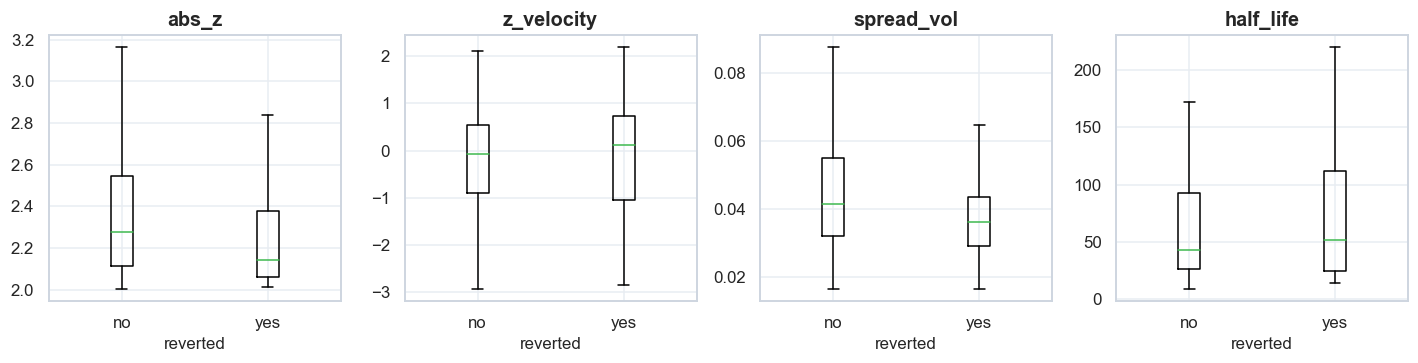

In [9]:
show = ["abs_z", "z_velocity", "spread_vol", "half_life"]
fig, axes = plt.subplots(1, len(show), figsize=(13, 3.4))
for ax, col in zip(axes, show):
    data = [events.loc[events.reverted==0, col], events.loc[events.reverted==1, col]]
    ax.boxplot(data, labels=["no", "yes"], showfliers=False)
    ax.set_title(col); ax.set_xlabel("reverted")
fig.tight_layout(); save_fig(fig, "prep_feature_by_class.png"); plt.show()

## Takeaways

- The pipeline produces a compact, fully causal event table ready for modeling.
- Class balance is moderate, so accuracy alone will be misleading; precision, recall and ROC/PR are the metrics that matter.
- Several features separate the classes at least mildly, so there is signal for a model to exploit. We test that next.